In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import scipy.io
import cv2
import os
import scipy as sp
from skimage.morphology import disk, reconstruction


In [2]:
# All the path 
projet_path = os.getcwd()
image_path = os.path.join(projet_path, "Lame_criblee")
mask_path = os.path.join(projet_path, "Terrain")

In [3]:
im_name = "LC001"
if os.path.exists(os.path.join(image_path, f"{im_name}.jpg")): 
    im = cv2.imread(f'{image_path}/{im_name}.jpg')
elif os.path.exists(os.path.join(image_path, f"{im_name}.png")):
    im = cv2.imread(f'{image_path}/{im_name}.png')
else : 
    print("The file path does not exist")
[H, W, I] = im.shape
#plt.imshow(im)
im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

In [4]:
# Charger le .mat
mat = scipy.io.loadmat(f'Terrain/{im_name}_VT.mat')
# Récupérer juste la matrice et la mettre dnas la varibale mask (car binaire)
mask = mat['seeds']
mask = mask * 255
#plt.imshow(mask, cmap=plt.cm.gray)

In [5]:
# Overlap image and mask
colormap = colors.ListedColormap(['white', 'red'])
#plt.imshow(im, cmap=plt.cm.gray)
#plt.imshow(mask, cmap = colormap, alpha = 0.2)

In [6]:
def quantification(im, mask):
    false_positives = np.sum((im == 255) & (mask == 0))
    false_negatives = np.sum((im == 0) & (mask == 255))
    true_positives = np.sum((im == 255) & (mask == 255))
    true_negatives = np.sum((im == 0) & (mask == 0))
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return false_positives, false_negatives, true_positives, true_negatives, precision, recall, f1_score

In [7]:
# Cleaning the dark rectangles
_, binary = cv2.threshold(im, 10, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
created_mask = np.ones(im.shape, dtype=np.uint8) * 255

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if (w > 20 and h > 20) and (x < 10 or x + w > im.shape[1] - 10):
        cv2.drawContours(created_mask, [contour], -1, 0, -1)

im[created_mask == 0] = 128
# plt.imshow(im, cmap = plt.cm.gray)

In [8]:
# Egalisation de l'histogramme de niveaux de gris
egal_image = cv2.equalizeHist(im)    
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].imshow(im, cmap = plt.cm.gray)
# axes[0].set_title('Original Image')
# axes[1].imshow(egal_image, cmap = plt.cm.gray)
# axes[1].set_title('Equal Image')

In [9]:
contrast_coeff = 1.6
brightness_coeff = 0 #coeff entre 1 et 3 (en dessous de 1, diminue le contrast)
brighter_image = egal_image*contrast_coeff+brightness_coeff
brighter_image = np.clip(brighter_image, 0, 255)  # Limit values to the range [0, 255]
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].imshow(egal_image, cmap='gray')
# axes[0].set_title('Original Image')
# axes[1].imshow(brighter_image, cmap='gray')
# axes[1].set_title('Adjusted Image')

[  0 255]
[  0 255]
7161 52696 33475 931462 0.8237769465498572 0.3884717596407144 0.5279676989440646


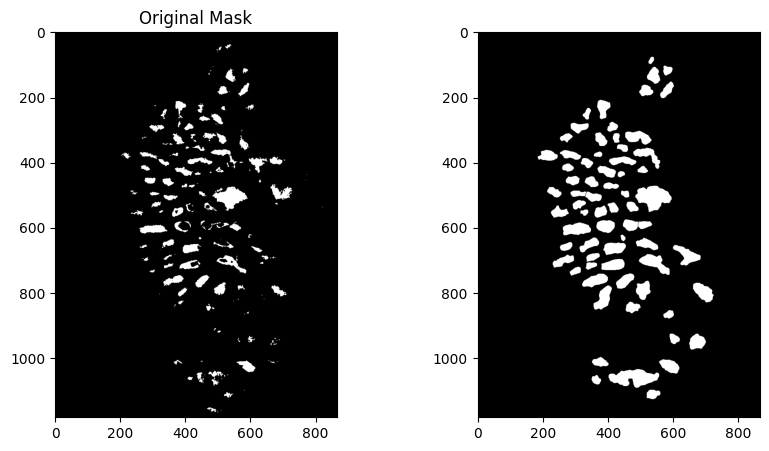

In [10]:
# Put a threshold on the image 
blur_im = cv2.GaussianBlur(egal_image,(5,5),0)
ret, seuil_im = cv2.threshold(blur_im, 10, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(seuil_im, cmap = plt.cm.gray)
axes[0].set_title('Recreated Image')
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[0].set_title('Original Mask')
FP, FN, TP, TN, precision, recall, f1_score = quantification(seuil_im, mask)
print(precision, recall, f1_score)

47998 22251 63920 890625 0.5711324362479673 0.741780877557415 0.6453664766847227


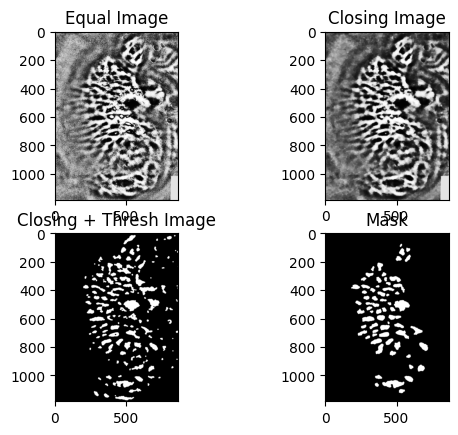

In [11]:
# Fill the missing spots inside the white structures and delete noise
SE3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
SE5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
SE7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
SE9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))

opening3 = cv2.morphologyEx(egal_image, cv2.MORPH_OPEN, SE7)
closing3 = cv2.morphologyEx(opening3, cv2.MORPH_CLOSE, SE9)
ret, close_seuil_im = cv2.threshold(closing3, 25, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(2, 2)
axes[0][0].imshow(egal_image, cmap = plt.cm.gray)
axes[0][0].set_title('Equal Image')
axes[0][1].imshow(closing3, cmap = plt.cm.gray)
axes[0][1].set_title('Closing Image')
axes[1][0].imshow(close_seuil_im, cmap = plt.cm.gray)
axes[1][0].set_title('Closing + Thresh Image')
axes[1][1].imshow(mask, cmap = plt.cm.gray)
axes[1][1].set_title('Mask')
FP, FN, TP, TN, precision, recall, f1_score = quantification(close_seuil_im, mask)
print(precision, recall, f1_score)

[  0 255]
[  0 255]
7161 55621 30550 931462 0.8101084564185517 0.3545276253031762 0.49321128170355666


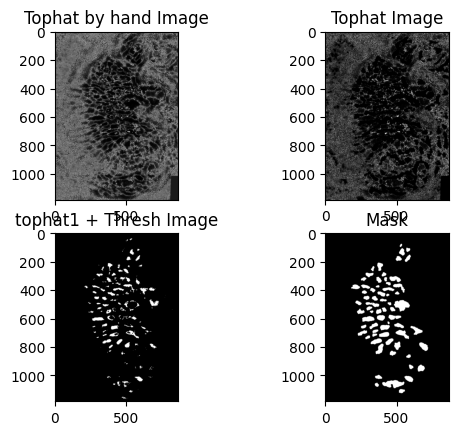

In [12]:
SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(35,35))
tophat_hand_im = brighter_image - opening3
tophat_im = cv2.morphologyEx(brighter_image, cv2.MORPH_TOPHAT, SE9)
seuil_tophat_im = cv2.morphologyEx(seuil_im, cv2.MORPH_TOPHAT, SE)
fig, axes = plt.subplots(2,2)
axes[0][0].imshow(tophat_hand_im, cmap = plt.cm.gray)
axes[0][0].set_title('Tophat by hand Image')
axes[0][1].imshow(tophat_im, cmap = plt.cm.gray)
axes[0][1].set_title('Tophat Image')
axes[1][0].imshow(seuil_tophat_im, cmap = plt.cm.gray)
axes[1][0].set_title('tophat1 + Thresh Image')
axes[1][1].imshow(mask, cmap = plt.cm.gray)
axes[1][1].set_title('Mask')
FP, FN, TP, TN, precision, recall, f1_score = quantification(seuil_tophat_im, mask)
print(precision, recall, f1_score)

6
862385 561 85610 76238 0.09030638347248666 0.993489689106544 0.16556336216816253


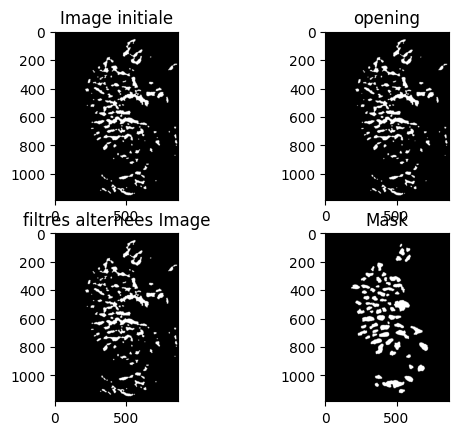

In [14]:
k=5
change = True
ret, seuil_filtres_im = cv2.threshold(closing3, 230, 255, cv2.THRESH_BINARY_INV)
init_opening = seuil_filtres_im
fig, axes = plt.subplots(2,2)
axes[0][0].imshow(init_opening-255, cmap = plt.cm.gray)
axes[0][0].set_title('Image initiale')
while change:
    k+=1
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
    closing = cv2.morphologyEx(init_opening, cv2.MORPH_CLOSE, SE)
    opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, SE)
    if opening.all() == init_opening.all():
        change = False
    init_opening = opening
axes[0][1].imshow(opening-255, cmap = plt.cm.gray)
axes[0][1].set_title('opening')
print(k)

ret, filtre_seuil_im = cv2.threshold(closing3, 230, 255, cv2.THRESH_BINARY_INV)
axes[1][0].imshow(filtre_seuil_im-255, cmap = plt.cm.gray)
axes[1][0].set_title('filtres alternees Image')
axes[1][1].imshow(mask, cmap = plt.cm.gray)
axes[1][1].set_title('Mask')
FP, FN, TP, TN, precision, recall, f1_score = quantification(filtre_seuil_im, mask)
print(FP, FN, TP, TN, precision, recall, f1_score)

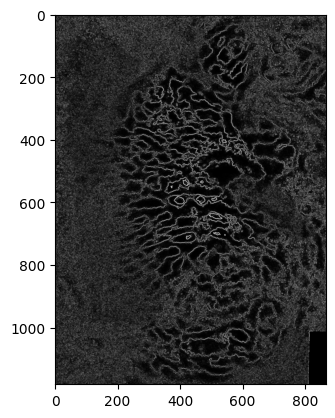

In [14]:
# Calcul du gradient 
grad_x = cv2.Sobel(egal_image, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(egal_image, cv2.CV_64F, 0, 1, ksize=3)

gradient_magnitude = cv2.magnitude(grad_x, grad_y)
gradient_magnitude = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX)
plt.imshow(gradient_magnitude, cmap='gray')

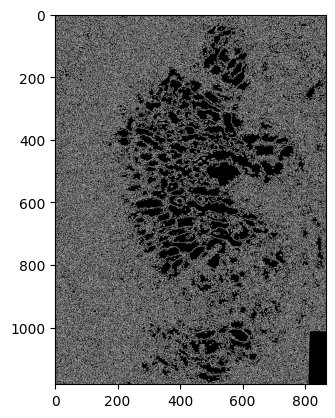

In [15]:
# canny edge detection 
canny_image = cv2.Canny(egal_image, 50,100)
plt.imshow(canny_image, cmap = plt.cm.gray)

In [16]:
def imfilter(im,noyau):
    # Creation du bordage en miroir 
    h,w = np.shape(noyau)
    hbis = int(np.floor(h/2))
    wbis = int(np.floor(w/2))
    im_bis = np.pad(im, ((hbis,hbis),(wbis,wbis)),'symmetric')
    [Hbis,Wbis] = im_bis.shape
    # Delete le bordage 
    conv = sp.signal.convolve2d(im_bis, noyau)
    conv_bis = conv[hbis:Hbis-hbis, wbis:Wbis-wbis]
    return conv_bis

In [ ]:
# Filtre dérivatuer, passe haut, dessine les contours 
def passeHaut(im): 
    noyauhoriz = np.array([[-1, 0, 1]])
    noyauvert = np.array([[-1], [0], [1]])

    imhoriz = imfilter(im,noyauhoriz)
    imvert = imfilter(im,noyauvert)
    imcontour = np.sqrt(imhoriz**2 + imvert**2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(im, cmap=plt.cm.gray)
    axes[1].imshow(imcontour, cmap=plt.cm.gray)

    return 
passeHaut(egal_image)

In [ ]:
# Noyau Lapalcien ou noyau dérivateur, fait apparaitre les coutours 
def laplacien(im, nb_voisins):
    if nb_voisins == 4 : 
        m_laplacien = [[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]]
    elif nb_voisins == 8 : 
        m_laplacien = [[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]]
    else : 
        return 0
    filtered_im = im*m_laplacien
    return filtered_im